In [19]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

## Import Library

Cell di atas adalah **library imports** yang digunakan dalam notebook ini:

### 1. **cv2 (OpenCV)**
   - Library untuk **Computer Vision**
   - Digunakan untuk pemrosesan citra (image processing)
   - Fungsi yang digunakan di project ini:
     - `cv2.cvtColor()` - Konversi format warna citra (RGB ke Grayscale, dll)
     - `cv2.GaussianBlur()` - Blur/smoothing citra
     - `cv2.filter2D()` - Konvolusi dengan kernel custom

### 2. **matplotlib.pyplot (plt)**
   - Library untuk **visualisasi data**
   - Digunakan untuk menampilkan dan menggambar citra
   - Fungsi yang digunakan di project ini:
     - `plt.imread()` - Membaca file citra dari disk
     - `plt.imshow()` - Menampilkan citra
     - `plt.subplots()` - Membuat multiple plots dalam satu figure
     - `plt.show()` - Menampilkan plot

### 3. **numpy (np)**
   - Library untuk **komputasi numerik**
   - Digunakan untuk operasi array/matrix
   - Fungsi yang digunakan di project ini:
     - Operasi array manipulation
     - Perhitungan matematika pada citra
     - Konversi data type citra

### **Tujuan:**
Ketiga library ini adalah tools utama untuk pemrosesan citra digital dan visualisasi hasil processing dalam praktikum PCD (Pengolahan Citra Digital).

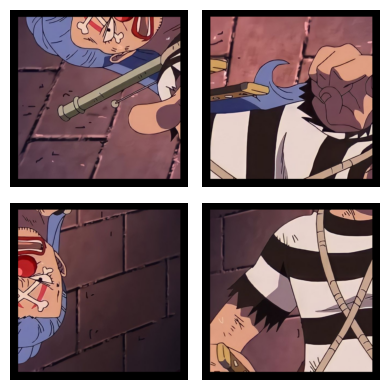

In [21]:
fig, axs = plt.subplots(2,2, figsize = (4,4))
axs[0,0].imshow(buggyA)
axs[0,0].axis('off')
axs[0,1].imshow(buggyB)
axs[0,1].axis('off')
axs[1,0].imshow(buggyC)
axs[1,0].axis('off')
axs[1,1].imshow(buggyD)
axs[1,1].axis('off')
plt.tight_layout()

## Visualisasi Citra Asli (Warna RGB)

Cell di atas melakukan **display/visualisasi citra buggy dalam format RGB**.

### Penjelasan Kode:

1. **`fig, axs = plt.subplots(2,2, figsize = (4,4))`**
   - Membuat figure dengan grid 2x2 (2 baris, 2 kolom)
   - `figsize = (4,4)` mengatur ukuran tampilan menjadi 4 inch × 4 inch
   - `fig` = figure object
   - `axs` = array of axes untuk setiap subplot

2. **`axs[i,j].imshow(buggyX)`**
   - Menampilkan citra pada position [i,j]
   - `axs[0,0]` = subplot atas-kiri → buggyA
   - `axs[0,1]` = subplot atas-kanan → buggyB
   - `axs[1,0]` = subplot bawah-kiri → buggyC
   - `axs[1,1]` = subplot bawah-kanan → buggyD

3. **`axs[i,j].axis('off')`**
   - Menghilangkan axis (sumbu x, y) pada setiap subplot
   - Membuat tampilan lebih bersih tanpa grid/angka axis

4. **`plt.tight_layout()`**
   - Mengatur jarak antar subplot otomatis
   - Mencegah overlapping antara subplot

### **Tujuan:**
Menampilkan keempat citra buggy dalam satu figure untuk perbandingan visual secara langsung dan efisien.

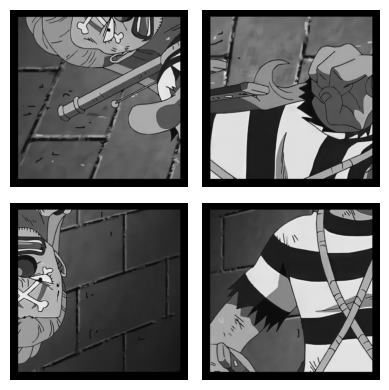

In [22]:
GrayBuggyA = cv2.cvtColor(buggyA, cv2.COLOR_BGR2GRAY)
GrayBuggyB = cv2.cvtColor(buggyB, cv2.COLOR_BGR2GRAY)
GrayBuggyC = cv2.cvtColor(buggyC, cv2.COLOR_BGR2GRAY)
GrayBuggyD = cv2.cvtColor(buggyD, cv2.COLOR_BGR2GRAY)

fig, axs = plt.subplots(2,2, figsize = (4,4))
axs[0,0].imshow(GrayBuggyA, cmap = 'grey')
axs[0,0].axis('off')
axs[0,1].imshow(GrayBuggyB, cmap = 'grey')
axs[0,1].axis('off')
axs[1,0].imshow(GrayBuggyC, cmap = 'grey')
axs[1,0].axis('off')
axs[1,1].imshow(GrayBuggyD, cmap = 'grey')
axs[1,1].axis('off')
plt.tight_layout()

## Konversi ke Grayscale dan Visualisasi

Cell di atas melakukan **konversi citra dari format warna RGB/BGR menjadi Grayscale (skala abu-abu)** dan menampilkannya.

### Penjelasan Kode:

#### 1. **Konversi BGR ke Grayscale**
```python
GrayBuggyA = cv2.cvtColor(buggyA, cv2.COLOR_BGR2GRAY)
GrayBuggyB = cv2.cvtColor(buggyB, cv2.COLOR_BGR2GRAY)
GrayBuggyC = cv2.cvtColor(buggyC, cv2.COLOR_BGR2GRAY)
GrayBuggyD = cv2.cvtColor(buggyD, cv2.COLOR_BGR2GRAY)
```
- `cv2.cvtColor()` = fungsi konversi warna dalam OpenCV
- `cv2.COLOR_BGR2GRAY` = parameter untuk konversi dari BGR ke Grayscale
- Hasil: citra 3-channel (RGB) → citra 1-channel (abu-abu)

#### 2. **Setup Grid Visualisasi**
```python
fig, axs = plt.subplots(2,2, figsize = (4,4))
```
- Membuat figure dengan grid 2×2
- Ukuran 4 inch × 4 inch

#### 3. **Menampilkan Citra Grayscale**
```python
axs[0,0].imshow(GrayBuggyA, cmap = 'grey')
```
- `imshow()` menampilkan citra
- `cmap = 'grey'` menggunakan colormap Abu-abu (appropriate untuk grayscale image)
- `axis('off')` menghilangkan label axis

#### 4. **Tata Letak Otomatis**
```python
plt.tight_layout()
```
- Mengatur spacing antar subplot

### **Tujuan:**
Mengubah citra berwarna menjadi grayscale (skala abu-abu) untuk preprocessing/analisis lebih lanjut. Grayscale lebih sederhana (1 channel vs 3 channel) dan lebih efisien untuk pemrosesan citra digital.

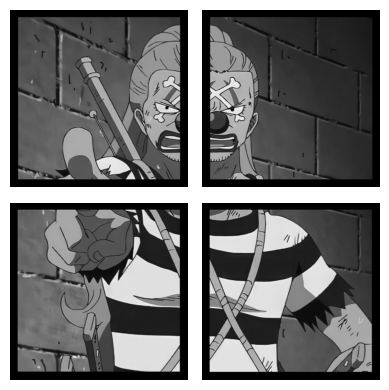

In [23]:
def fliphorizontal(image):
    hasil = []
    for baris in image:
        baris_baru = []
        for i in range(len(baris)-1, -1, -1):
            baris_baru.append(baris[i])
        hasil.append(baris_baru)
    return hasil

def flipvertikal(image):
    hasil = []
    for i in range(len(image)-1, -1, -1):
        hasil.append(image[i])
    return hasil

def rotate90sjj(image):
    height = len(image)
    width = len(image[0])
    
    rotated = [[0] * height for _ in range(width)]
    
    for i in range(height):
        for j in range(width):
            rotated[j][height - 1 - i] = image[i][j]
    
    return rotated

def rotate90bjj(image):
    height = len(image)
    width = len(image[0])

    rotated = [[0] * height for _ in range(width)]
    
    for i in range(height):
        for j in range(width):
            rotated[width - 1 - j][i] = image[i][j]
    
    return rotated
grayrotateA = rotate90sjj(GrayBuggyA)
grayrotateB = rotate90bjj(GrayBuggyB)
grayflipD = fliphorizontal(GrayBuggyD)
grayflipC = flipvertikal(GrayBuggyC)
fig, axs = plt.subplots(2,2, figsize = (4,4))
axs[0,0].imshow(grayrotateA, cmap = 'grey')
axs[0,0].axis('off')
axs[0,1].imshow(grayflipC, cmap = 'grey')
axs[0,1].axis('off')
axs[1,0].imshow(grayrotateB, cmap = 'grey')
axs[1,0].axis('off')
axs[1,1].imshow(grayflipD, cmap = 'grey')
axs[1,1].axis('off')
plt.tight_layout()

## Transformasi Geometri (Rotasi & Flip)

Cell di atas melakukan **definisi dan aplikasi transformasi geometri** pada citra grayscale: rotasi dan flip (horizontal/vertikal).

### Fungsi-Fungsi yang Didefinisikan:

#### 1. **`fliphorizontal(image)`**
- Membalik citra secara horizontal (cermin kiri-kanan)
- Iterasi setiap baris dari kanan ke kiri

#### 2. **`flipvertikal(image)`**
- Membalik citra secara vertikal (cermin atas-bawah)
- Iterasi setiap baris dari bawah ke atas

#### 3. **`rotate90sjj(image)`** (Searah Jarum Jam)
- Rotasi citra 90 derajat searah jarum jam
- Formula: `rotated[j][height - 1 - i] = image[i][j]`

#### 4. **`rotate90bjj(image)`** (Berlawanan Arah Jarum Jam)
- Rotasi citra 90 derajat berlawanan arah jarum jam
- Formula: `rotated[width - 1 - j][i] = image[i][j]`

### Aplikasi pada Grayscale Images:
```python
grayrotateA = rotate90sjj(GrayBuggyA)      # BuggyA rotasi 90° CW
grayrotateB = rotate90bjj(GrayBuggyB)      # BuggyB rotasi 90° CCW
grayflipD = fliphorizontal(GrayBuggyD)     # BuggyD flip horizontal
grayflipC = flipvertikal(GrayBuggyC)       # BuggyC flip vertikal
```

### Digunakan untuk Cell Selanjutnya:
Cell berikutnya akan menggunakan hasil transformasi ini (`grayrotateA`, `grayrotateB`, `grayflipC`, `grayflipD`) sebagai **input untuk fungsi `hapuspadding()`** yang akan menghilangkan area kosong/padding di sekitar objek dalam citra yang telah ditransformasi.

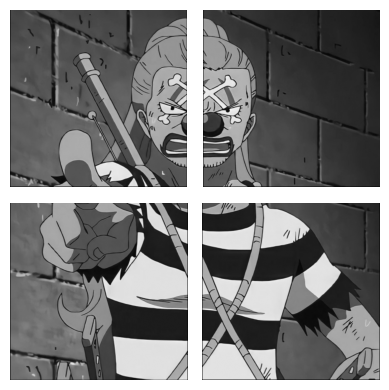

In [31]:
def hapuspadding(image):
    import numpy as np
    img = np.array(image, dtype=np.float32)

    if img.ndim == 3:
        img = img[:, :, 0]

    mask_baris = np.any(img > 0.05, axis=1)
    mask_kolom = np.any(img > 0.05, axis=0)

    baris_valid = np.where(mask_baris)[0]
    kolom_valid = np.where(mask_kolom)[0]

    if len(baris_valid) == 0 or len(kolom_valid) == 0:
        return image

    atas = baris_valid[0]
    bawah = baris_valid[-1] + 1
    kiri = kolom_valid[0]
    kanan = kolom_valid[-1] + 1

    return img[atas:bawah, kiri:kanan].tolist()


nopaddingA = hapuspadding(grayrotateA)
nopaddingB = hapuspadding(grayrotateB)
nopaddingC = hapuspadding(grayflipC)
nopaddingD = hapuspadding(grayflipD)

fig, axs = plt.subplots(2,2, figsize = (4,4))
axs[0,0].imshow(nopaddingA, cmap = 'grey')
axs[0,0].axis('off')
axs[0,1].imshow(nopaddingC, cmap = 'grey')
axs[0,1].axis('off')
axs[1,0].imshow(nopaddingB, cmap = 'grey')
axs[1,0].axis('off')
axs[1,1].imshow(nopaddingD, cmap = 'grey')
axs[1,1].axis('off')
plt.tight_layout()

## Menghapus Padding (Crop Citra)

Cell di atas melakukan **definisi dan aplikasi fungsi `hapuspadding()`** yang menghilangkan area kosong (padding/border) di sekitar objek pada citra yang telah ditransformasi.

### Proses Fungsi `hapuspadding()`:

#### 1. **Konversi ke NumPy Array**
```python
img = np.array(image, dtype=np.float32)
if img.ndim == 3:
    img = img[:, :, 0]  # Ambil channel pertama jika 3D
```
- Konversi citra list ke numpy array
- Jika citra memiliki 3 dimensi, ambil hanya channel pertama

#### 2. **Deteksi Pixel Tidak Kosong**
```python
mask_baris = np.any(img > 0.05, axis=1)  # Cek per baris
mask_kolom = np.any(img > 0.05, axis=0)  # Cek per kolom
```
- Mencari baris yang memiliki minimal 1 pixel dengan nilai > 0.05
- Mencari kolom yang memiliki minimal 1 pixel dengan nilai > 0.05

#### 3. **Menemukan Batas Objek**
```python
baris_valid = np.where(mask_baris)[0]  # Index baris dengan objek
kolom_valid = np.where(mask_kolom)[0]  # Index kolom dengan objek
atas = baris_valid[0]      # Baris pertama dengan objek
bawah = baris_valid[-1] + 1 # Baris terakhir dengan objek
kiri = kolom_valid[0]       # Kolom pertama dengan objek
kanan = kolom_valid[-1] + 1 # Kolom terakhir dengan objek
```

#### 4. **Crop Citra**
```python
return img[atas:bawah, kiri:kanan].tolist()
```
- Memotong (crop) citra hingga hanya menyisakan area dengan objek

### Aplikasi pada Keempat Citra:
```python
nopaddingA = hapuspadding(grayrotateA)
nopaddingB = hapuspadding(grayrotateB)
nopaddingC = hapuspadding(grayflipC)
nopaddingD = hapuspadding(grayflipD)
```

### Digunakan untuk Cell Selanjutnya:
Keempat hasil padding removal (`nopaddingA`, `nopaddingB`, `nopaddingC`, `nopaddingD`) akan menjadi **input untuk fungsi `merged()`** di cell berikutnya, yang akan:
1. Menghitung dimensi (tinggi & lebar) terkecil dari keempat citra
2. Menggabungkan keempat citra menjadi satu canvas 2×2 dengan ukuran yang seragam
3. Menghasilkan `after_merged` yang merupakan gabungan ke-4 citra

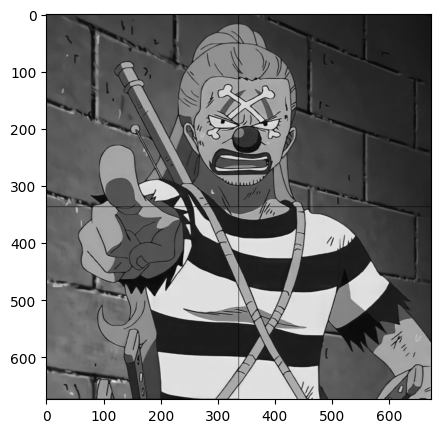

In [77]:
def merged(nopaddingA, nopaddingB, nopaddingC, nopaddingD):
    tA = 0
    for _ in nopaddingA: tA += 1
    tB = 0
    for _ in nopaddingB: tB += 1
    tC = 0
    for _ in nopaddingC: tC += 1
    tD = 0
    for _ in nopaddingD: tD += 1

    lA = 0
    for _ in nopaddingA[0]: lA += 1
    lB = 0
    for _ in nopaddingB[0]: lB += 1
    lC = 0
    for _ in nopaddingC[0]: lC += 1
    lD = 0
    for _ in nopaddingD[0]: lD += 1

    tinggi = min(tA, tB, tC, tD)
    lebar  = min(lA, lB, lC, lD)

    hasil_gabung = np.zeros((tinggi * 2, lebar * 2)).tolist()
    for i in range(tinggi):
        for j in range(lebar):
            hasil_gabung[i][j]                = nopaddingA[i][j]
            hasil_gabung[i][j + lebar]         = nopaddingB[i][j]
            hasil_gabung[i + tinggi][j]      = nopaddingC[i][j]
            hasil_gabung[i + tinggi][j + lebar] = nopaddingD[i][j]
    return hasil_gabung

after_merged = merged(nopaddingA, nopaddingC, nopaddingB, nopaddingD)

plt.figure(figsize=(12,5))
plt.imshow(after_merged, cmap='gray')
plt.show()

## Merge Citra (Penggabungan 4 Citra)

Cell di atas melakukan **definisi dan aplikasi fungsi `merged()`** yang menggabungkan keempat citra yang sudah di-crop menjadi satu canvas dengan layout 2×2.

### Proses Fungsi `merged()`:

#### 1. **Hitung Dimensi Setiap Citra**
```python
tA, tB, tC, tD = 0, 0, 0, 0  # Tinggi
lA, lB, lC, lD = 0, 0, 0, 0  # Lebar

for _ in nopaddingA: tA += 1  # Hitung baris
for _ in nopaddingA[0]: lA += 1  # Hitung kolom
```
- Menghitung tinggi (jumlah baris) masing-masing citra
- Menghitung lebar (jumlah kolom) masing-masing citra

#### 2. **Tentukan Dimensi Minimum**
```python
tinggi = min(tA, tB, tC, tD)
lebar  = min(lA, lB, lC, lD)
```
- Mengambil tinggi terkecil dari 4 citra
- Mengambil lebar terkecil dari 4 citra
- Tujuan: Menyamakan ukuran agar bisa digabung tanpa distorsi

#### 3. **Buat Canvas Gabungan 2×2**
```python
hasil_gabung = np.zeros((tinggi * 2, lebar * 2)).tolist()
```
- Membuat canvas dengan ukuran (tinggi×2, lebar×2)
- Layout: 
  - `[0:tinggi, 0:lebar]` → nopaddingA
  - `[0:tinggi, lebar:2*lebar]` → nopaddingB
  - `[tinggi:2*tinggi, 0:lebar]` → nopaddingC
  - `[tinggi:2*tinggi, lebar:2*lebar]` → nopaddingD

#### 4. **Copy Piksel ke Canvas**
```python
untuk i in range(tinggi):
    untuk j in range(lebar):
        hasil_gabung[i][j] = nopaddingA[i][j]
        hasil_gabung[i][j + lebar] = nopaddingB[i][j]
        hasil_gabung[i + tinggi][j] = nopaddingC[i][j]
        hasil_gabung[i + tinggi][j + lebar] = nopaddingD[i][j]
```

### Output yang Dihasilkan:
- `after_merged` = citra gabungan 4 citra dalam layout 2×2

### Digunakan untuk Cell Selanjutnya:
`after_merged` akan menjadi **input untuk preprocessing histogram** yang akan:
1. Membagi nilai piksel dengan 2 → `citra_bagi2`
2. Menghitung histogram awal (sebelum normalisasi)
3. Melakukan normalisasi piksel ke range 0-255 → `citra_norm`
4. Menghitung histogram setelah normalisasi
5. Membandingkan kedua histogram secara visual dalam bar chart

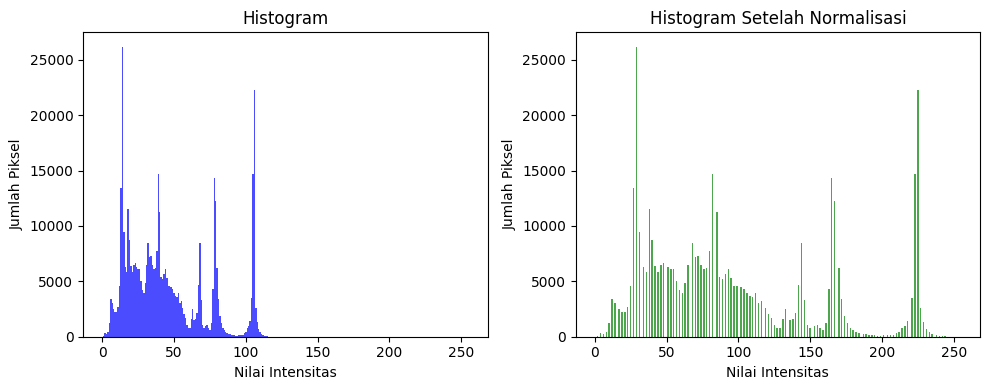

In [90]:
tinggi = 0
for _ in after_merged: tinggi += 1
lebar = 0
for _ in after_merged[0]: lebar += 1

citra_bagi2 = np.zeros((tinggi, lebar)).tolist()
for i in range(tinggi):
    for j in range(lebar):
        citra_bagi2[i][j] = int(after_merged[i][j] * 255) // 2

def hitung_histogram(image):
    hist = [0] * 256
    for baris in image:
        for piksel in baris:
            hist[int(piksel)] += 1
    return hist

hist_sebelum = hitung_histogram(citra_bagi2)

semua_piksel = [citra_bagi2[i][j] for i in range(tinggi) for j in range(lebar)]
min_val = min(semua_piksel)
max_val = max(semua_piksel)

citra_norm = [[0 for _ in range(lebar)] for _ in range(tinggi)]
for i in range(tinggi):
    for j in range(lebar):
        citra_norm[i][j] = int((citra_bagi2[i][j] - min_val) / (max_val - min_val) * 255)

hist_sesudah = hitung_histogram(citra_norm)

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

axs[0].bar(range(256), hist_sebelum, color="blue", alpha=0.7, width=1)
axs[0].set_title("Histogram")
axs[0].set_xlabel("Nilai Intensitas")
axs[0].set_ylabel("Jumlah Piksel")

axs[1].bar(range(256), hist_sesudah, color="green", alpha=0.7, width=1)
axs[1].set_title("Histogram Setelah Normalisasi")
axs[1].set_xlabel("Nilai Intensitas")
axs[1].set_ylabel("Jumlah Piksel")

plt.tight_layout()
plt.show()

## Histogram dan Normalisasi Intensitas

Cell di atas melakukan **perhitungan histogram dan normalisasi intensitas piksel** pada citra gabungan, kemudian membandingkannya secara visual.

### Proses:

#### 1. **Hitung Dimensi Citra**
```python
tinggi = 0
for _ in after_merged: tinggi += 1
lebar = 0
for _ in after_merged[0]: lebar += 1
```
- Menghitung tinggi dan lebar dari citra gabungan

#### 2. **Pembagian Nilai Piksel**
```python
citra_bagi2 = np.zeros((tinggi, lebar)).tolist()
for i in range(tinggi):
    for j in range(lebar):
        citra_bagi2[i][j] = int(after_merged[i][j] * 255) // 2
```
- Mengalikan nilai piksel dengan 255 dan membagi 2
- Tujuan: Mengecilkan range intensitas untuk persiapan normalisasi

#### 3. **Definisi Fungsi Histogram**
```python
def hitung_histogram(image):
    hist = [0] * 256
    for baris in image:
        for piksel in baris:
            hist[int(piksel)] += 1
    return hist
```
- Menghitung jumlah piksel untuk setiap nilai intensitas (0-255)
- Menghasilkan array 256 elemen

#### 4. **Hitung Histogram Sebelum Normalisasi**
```python
hist_sebelum = hitung_histogram(citra_bagi2)
```

#### 5. **Normalisasi Piksel**
```python
semua_piksel = [citra_bagi2[i][j] for i in range(tinggi) for j in range(lebar)]
min_val = min(semua_piksel)
max_val = max(semua_piksel)

citra_norm = [[0 for _ in range(lebar)] for _ in range(tinggi)]
for i in range(tinggi):
    for j in range(lebar):
        citra_norm[i][j] = int((citra_bagi2[i][j] - min_val) / (max_val - min_val) * 255)
```
- Mencari nilai minimum dan maksimum
- Normalisasi ke range 0-255 dengan rumus: `(piksel - min) / (max - min) × 255`
- Tujuan: Memaksimalkan kontras citra

#### 6. **Hitung Histogram Setelah Normalisasi**
```python
hist_sesudah = hitung_histogram(citra_norm)
```

#### 7. **Visualisasi Perbandingan Histogram**
- Menampilkan 2 bar chart: histogram sebelum dan sesudah normalisasi
- Histogram sebelum berwarna biru
- Histogram setelah normalisasi berwarna hijau

### Digunakan untuk Cell Selanjutnya:
Output `citra_norm` (citra yang sudah dinormalisasi) akan menjadi **input untuk proses padding dan konvolusi** di cell berikutnya, yang akan:
1. Menambahkan padding (border) pada citra
2. Melakukan filtering menggunakan kernel convolution 4×4
3. Menghasilkan citra hasil konvolusi (`citra_conv`)

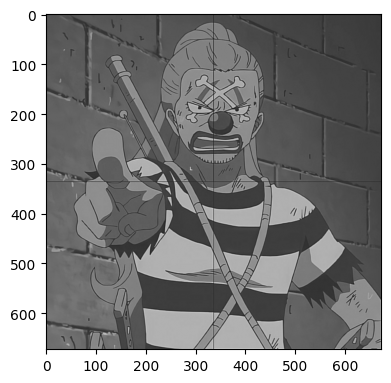

In [86]:
pad   = 1
h_pad = tinggi + 2 * pad
w_pad = lebar  + 2 * pad

citra_pad = np.zeros((h_pad, w_pad)).tolist()
for i in range(tinggi):
    for j in range(lebar):
        citra_pad[i + pad][j + pad] = citra_norm[i][j]

kernel = [
    [-1/10, -1/10, -1/10, -1/10],
    [-1/10,  6/10,  6/10, -1/10],
    [-1/10,  6/10,  6/10, -1/10],
    [-1/10, -1/10, -1/10, -1/10]
]
kH, kW = 4, 4
outH = h_pad - kH + 1
outW = w_pad - kW + 1

citra_conv = np.zeros((outH, outW)).tolist()
for i in range(outH):
    for j in range(outW):
        total = 0.0
        for ki in range(kH):
            for kj in range(kW):
                total += citra_pad[i + ki][j + kj] * kernel[ki][kj]
        citra_conv[i][j] = total

plt.figure(figsize=(4, 4))
plt.imshow(citra_conv, cmap="gray")
plt.tight_layout()
plt.show()

## Padding dan Konvolusi (Filtering)

Cell di atas melakukan **padding pada citra dan proses konvolusi menggunakan kernel filtering 4×4** untuk melakukan image enhancement/filtering pada citra yang sudah dinormalisasi.

### Proses:

#### 1. **Setup Padding Parameter**
```python
pad   = 1
h_pad = tinggi + 2 * pad      # tinggi_baru = tinggi + 2
w_pad = lebar  + 2 * pad      # lebar_baru = lebar + 2
```
- Menambahkan border/padding sebesar 1 piksel di semua sisi
- Tujuan: Mencegah kehilangan piksel pada tepi saat konvolusi

#### 2. **Buat Citra Berpadding**
```python
citra_pad = np.zeros((h_pad, w_pad)).tolist()
for i in range(tinggi):
    for j in range(lebar):
        citra_pad[i + pad][j + pad] = citra_norm[i][j]
```
- Membuat citra baru dengan ukuran (h_pad, w_pad) berisi 0
- Menempatkan citra asli di tengah (dikelilingi border 0)
- Hasil: citra yang sudah dipadding

#### 3. **Definisi Kernel Filtering**
```python
kernel = [
    [-1/10, -1/10, -1/10, -1/10],
    [-1/10,  6/10,  6/10, -1/10],
    [-1/10,  6/10,  6/10, -1/10],
    [-1/10, -1/10, -1/10, -1/10]
]
kH, kW = 4, 4
```
- Kernel 4×4 untuk filtering
- Tipe: Laplacian-like kernel untuk edge enhancement/sharpening
- Nilai center lebih tinggi (0.6) untuk memperkuat fitur tengah

#### 4. **Hitung Dimensi Output**
```python
outH = h_pad - kH + 1
outW = w_pad - kW + 1
```
- Formula: output_size = (input_size - kernel_size + 1)
- Contoh: jika h_pad=150, kH=4 → outH = 150 - 4 + 1 = 147

#### 5. **Operasi Konvolusi (Proses Inti)**
```python
citra_conv = np.zeros((outH, outW)).tolist()
for i in range(outH):
    for j in range(outW):
        total = 0.0
        for ki in range(kH):
            for kj in range(kW):
                total += citra_pad[i + ki][j + kj] * kernel[ki][kj]
        citra_conv[i][j] = total
```

**Penjelasan:**
- Untuk setiap posisi (i, j) pada output
- Ekstrak region 4×4 dari citra_pad
- Kalikan element-wise dengan kernel
- Jumlahkan semua hasil (dot product)
- Simpan hasil di citra_conv[i][j]

#### 6. **Visualisasi Hasil Konvolusi**
```python
plt.figure(figsize=(4, 4))
plt.imshow(citra_conv, cmap="gray")
plt.show()
```
- Menampilkan hasil filtering

### Output yang Dihasilkan:
- `citra_conv` = citra hasil konvolusi dengan kernel 4×4

### Aplikasi untuk Cell Selanjutnya atau Proses Berikutnya:
Hasil konvolusi (`citra_conv`) dapat digunakan untuk:
1. **Deteksi Tepi (Edge Detection)** - mengidentifikasi batas objek
2. **Peningkatan Kontras (Sharpening)** - membuat fitur lebih jelas
3. **Klasifikasi Fitur** - mengekstrak feature untuk machine learning
4. **Analisis Tekstur** - mengidentifikasi pola dalam citra
5. **Preprocessing untuk CNN** - persiapan input neural network